In [57]:
!pip install pandas
!pip install sqlite3
!pip install matplotlib

ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 55.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 70.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 78.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [58]:
import os
import matplotlib.pyplot as plt

In [24]:
import pandas as pd 

df = pd.read_csv('red_30_tech_us_sales.csv')

In [25]:
df.head()

,EmpID,OrderNum,OrderDate,OrderType,Quantity,Price,Discount,Order Total
0,900015476,1100948,9/3/2017,Retail,1,$44.95,0,$44.95
1,900015476,1101096,9/24/2017,Wholesale,10,$4.99,$1.00,$48.90
2,900015476,1101138,10/1/2017,Wholesale,4,$250.00,$50.00,$950.00
3,900015476,1101158,10/3/2017,Retail,1,$250.00,0,$250.00
4,900015476,1101181,10/9/2017,Retail,1,$13.99,0,$13.99


In [28]:
df.columns

Index(['EmpID ', 'OrderNum', 'OrderDate', 'OrderType', 'Quantity', ' Price ',
       ' Discount ', ' Order Total '],
      dtype='str')

In [29]:
df = df.rename(columns={
    "EmpID ": "EmpID",
    " Price ": "Price",
    " Discount ": "Discount",
    " Order Total ": "OrderTotal"
})

In [30]:
df['OrderTotal'] = df['OrderTotal'].astype(str).str.replace(r'[\s"$#,]', '', regex=True).astype(float)

In [31]:
df['Price'] = df['Price'].astype(str).str.replace(r'[\s"$#,]', '', regex=True).astype(float)
df['Discount'] = df['Discount'].astype(str).str.replace(r'[\s"$#,]', '', regex=True).astype(float)
df.head()

,EmpID,OrderNum,OrderDate,OrderType,Quantity,Price,Discount,OrderTotal
0,900015476,1100948,9/3/2017,Retail,1,44.95,0.0,44.95
1,900015476,1101096,9/24/2017,Wholesale,10,4.99,1.0,48.90
2,900015476,1101138,10/1/2017,Wholesale,4,250.00,50.0,950.00
3,900015476,1101158,10/3/2017,Retail,1,250.00,0.0,250.00
4,900015476,1101181,10/9/2017,Retail,1,13.99,0.0,13.99


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4976 entries, 0 to 4975
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EmpID       4976 non-null   int64  
 1   OrderNum    4976 non-null   int64  
 2   OrderDate   4976 non-null   str    
 3   OrderType   4976 non-null   str    
 4   Quantity    4976 non-null   int64  
 5   Price       4976 non-null   float64
 6   Discount    4976 non-null   float64
 7   OrderTotal  4976 non-null   float64
dtypes: float64(3), int64(3), str(2)
memory usage: 311.1 KB


In [33]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='%m/%d/%Y')

In [35]:
df['OrderDate_null'] = df['OrderDate'].isnull()
condition = df['Quantity'].isnull() & (df['OrderDate_null'] == False)
df.loc[condition, 'Quantity'] = (df['OrderTotal'] + df['Discount']) / df['Price']

In [36]:
df[df.duplicated()]

,EmpID,OrderNum,OrderDate,OrderType,Quantity,Price,Discount,OrderTotal,OrderDate_null


In [38]:
df_no_dupes = df.drop_duplicates()

In [39]:
df_no_dupes.to_csv('red_30_tech_us_sales_cleaned.csv', index=False)

In [40]:
#read data from googlesheets
def get_data_from_google_sheet(sheet_url):
    csv_url = sheet_url.replace('/edit?usp=sharing', '/export?format=csv')
    
    try:
        df = pd.read_csv(csv_url)
        
        expected_columns = ['state_name', 'state_code', 'state_timezone']
        
        if all(col in df.columns for col in expected_columns):
            df = df[expected_columns]
        else:
            print("Expected columns are not found in the DataFrame")
            return None
        
        return df
    
    except Exception as e:
        print(f"Error fetching data: {e}")
        return None

sheet_url = "https://docs.google.com/spreadsheets/d/1I31B5NN7tFYntmATiEE_PiQhZ47DsAXetiDrVsVehfM/edit?usp=sharing"
df = get_data_from_google_sheet(sheet_url)

if df is not None:
    print(df.head())

   state_name state_code                                 state_timezone
0     Alabama         AL                              Central Time (CT)
1      Alaska         AK  Alaska Time (AKT), Hawaii-Aleutian Time (HAT)
2     Arizona         AZ                            Mountain Time (MT)*
3    Arkansas         AR                              Central Time (CT)
4  California         CA                              Pacific Time (PT)


In [45]:
import sqlite3
conn = sqlite3.connect('database.db')

In [46]:
df.to_sql('us_state_codes', conn, if_exists='replace',index=False)

50

In [47]:
df['state_timezone'] = df['state_timezone'].str.replace('*', '', regex=False)

In [ ]:
#update existing table in db
table_name = 'us_state_codes'
identifier_column = 'state_name'

try:
    existing_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)

    merged_df = pd.merge(existing_df, df, on=identifier_column, how='outer', suffixes=('_old', '_new'))

    update_mask = merged_df[identifier_column].isin(existing_df[identifier_column]) & merged_df[identifier_column].isin(df[identifier_column])

    for col in df.columns:
        if col != identifier_column and f'{col}_new' in merged_df.columns:
            merged_df.loc[update_mask, col] = merged_df[f'{col}_new']

    final_df = merged_df[df.columns]

except pd.io.sql.DatabaseError:
    final_df = df

final_df.to_sql(table_name, conn, if_exists='replace', index=False)

print(f"Data in table '{table_name}' has been merged/updated.")

conn.close

Data in table 'us_state_codes' has been merged/updated.


<function Connection.close()>

In [59]:
df = pd.read_csv('red_30_tech_us_sales_cleaned.csv')
sum_sales_quantity = df.groupby('EmpID')['Quantity'].sum()
mean_sales_quantity = df.groupby('EmpID')['Quantity'].mean()
min_sales_quantity = df.groupby('EmpID')['Quantity'].min()
max_sales_quantity = df.groupby('EmpID')['Quantity'].max()

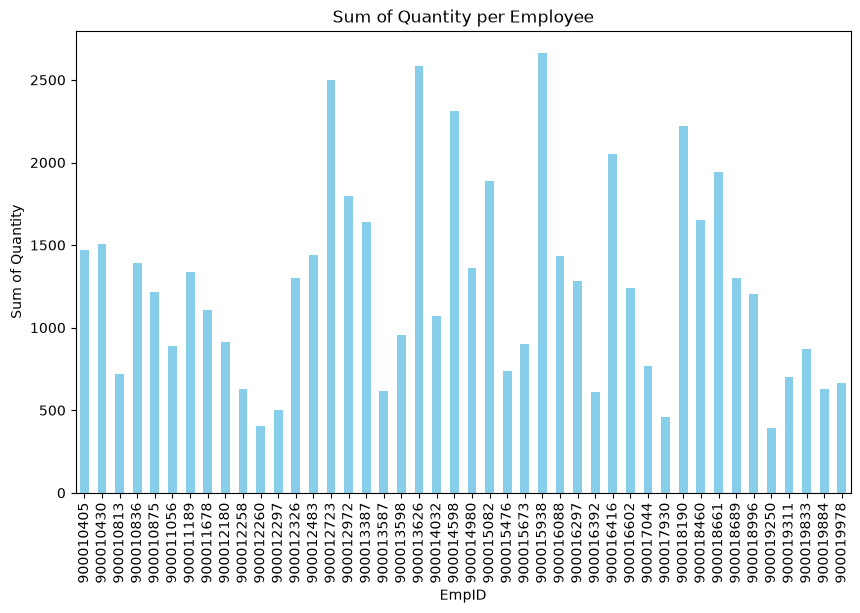

In [60]:
import matplotlib.pyplot as plt

sum_sales_quantity.plot(kind='bar', figsize=(10, 6), color='skyblue')

plt.xlabel('EmpID')
plt.ylabel('Sum of Quantity')
plt.title('Sum of Quantity per Employee')

plt.show()

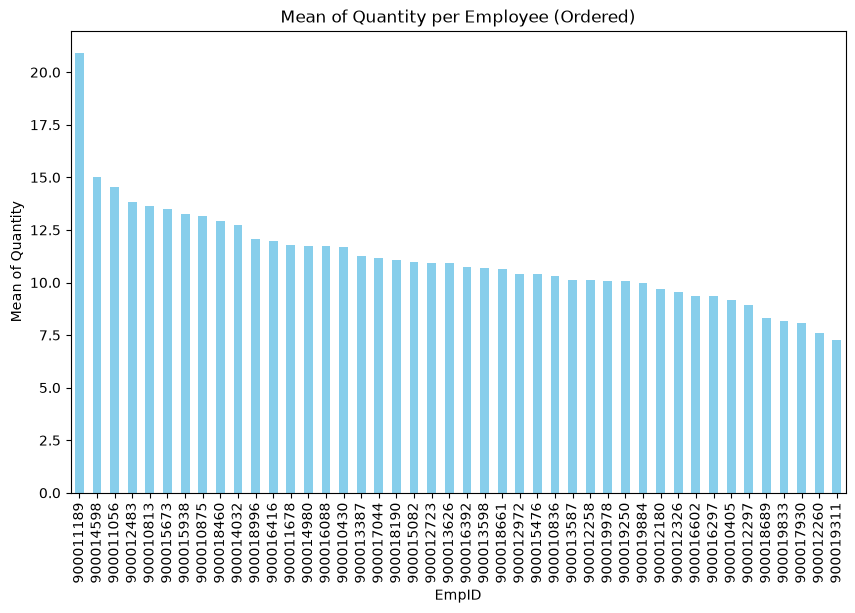

In [61]:
sorted_mean_sales_quantity = mean_sales_quantity.sort_values(ascending=False)

sorted_mean_sales_quantity.plot(kind='bar', figsize=(10, 6), color='skyblue')

plt.xlabel('EmpID')
plt.ylabel('Mean of Quantity')
plt.title('Mean of Quantity per Employee (Ordered)')

plt.show()

In [62]:
summary_metrics_df = pd.DataFrame({
	'EmpID': sum_sales_quantity.index,
	'Sum_Quantity': sum_sales_quantity.values,
	'Mean_Quantity': mean_sales_quantity.values,
	'Min_Quantity': min_sales_quantity.values,
	'Max_Quantity': max_sales_quantity.values
})

print(summary_metrics_df)

        EmpID  Sum_Quantity  Mean_Quantity  Min_Quantity  Max_Quantity
0   900010405          1473       9.149068             1           102
1   900010430          1508      11.689922             1           108
2   900010813           722      13.622642             1            99
3   900010836          1391      10.303704             1           108
4   900010875          1213      13.184783             1           101
5   900011056           887      14.540984             1           103
6   900011189          1339      20.921875             1           101
7   900011678          1108      11.787234             1           105
8   900012180           913       9.712766             1            95
9   900012258           628      10.129032             1            64
10  900012260           402       7.584906             1            96
11  900012297           500       8.928571             1            94
12  900012326          1298       9.544118             1           109
13  90

In [70]:
sales_associates_df = pd.read_csv('red_30_tech_us_sales_associates.csv')

merged_df = summary_metrics_df.merge(sales_associates_df, on='EmpID', how='inner')

In [71]:
merged_df.columns

Index(['EmpID', 'Sum_Quantity', 'Mean_Quantity', 'Min_Quantity',
       'Max_Quantity', 'Employee Name', 'Job title', 'Region', 'Start Date',
       'End date', 'First_name', 'Last_name'],
      dtype='str')

In [73]:
merged_df = merged_df.assign(
    StartDate=pd.to_datetime(merged_df['Start Date']),
    EndDate=pd.to_datetime(merged_df['End date'])
)

merged_df = merged_df.assign(EmploymentDurationDays=(merged_df['EndDate'] - merged_df['StartDate']).dt.days)

In [75]:
merged_df = merged_df.assign(
    StartDate=pd.to_datetime(merged_df['StartDate']),
    EndDate=pd.to_datetime(merged_df['EndDate'].fillna('2020-01-01'))
)

merged_df = merged_df.assign(EmploymentDurationDays=(merged_df['EndDate'] - merged_df['StartDate']).dt.days)

#merged_df.head(44)

In [76]:
merged_df = merged_df.assign(SalesPerDay=merged_df['Sum_Quantity'] / merged_df['EmploymentDurationDays'].replace(0, 1))

In [79]:
merged_df.to_csv('us_sales_statistics_by_associate.csv',index=False)

In [54]:
conn = sqlite3.connect('database.db')

csv_directory = '.'

for filename in os.listdir(csv_directory):
    if filename.endswith('.csv'):
        file_path = os.path.join(csv_directory, filename)
        df = pd.read_csv(file_path)

        table_name = filename.replace('.csv', '')

        df.to_sql(table_name, conn, if_exists='replace', index=False)
        print(f"Loaded {filename} into the database as {table_name}")

conn.close()

Loaded red_30_tech_us_sales.csv into the database as red_30_tech_us_sales
Loaded red_30_tech_us_sales_associates.csv into the database as red_30_tech_us_sales_associates
Loaded red_30_tech_us_sales_cleaned.csv into the database as red_30_tech_us_sales_cleaned
Loaded red_30_tech_us_product_info.csv into the database as red_30_tech_us_product_info
Loaded red_30_tech_us_customer_info.csv into the database as red_30_tech_us_customer_info
Loaded red_30_tech_us_sales_regions.csv into the database as red_30_tech_us_sales_regions


In [78]:
pd.read_csv('us_sales_statistics_by_associate.csv')

,Unnamed: 0,EmpID,Sum_Quantity,Mean_Quantity,Min_Quantity,Max_Quantity,Employee Name,Job title,Region,Start Date,End date,First_name,Last_name,StartDate,EndDate,EmploymentDurationDays,SalesPerDay
0,0,900010405,1473,9.149068,1,102,Ara Dumbreck,Sales Representative,N Central East,8/27/2019,NaN,Ara,Dumbreck,2019-08-27,2020-01-01,127,11.598425
1,1,900010430,1508,11.689922,1,108,Jason Bellamy,Senior Sales Representative,Central East,2/25/2003,NaN,Jason,Eisold,2003-02-25,2020-01-01,6154,0.245044
2,2,900010813,722,13.622642,1,99,Willow Townsend,Senior Sales Representative,Northwest,11/10/2008,NaN,Willow,Tunnick,2008-11-10,2020-01-01,4069,0.177439
3,3,900010836,1391,10.303704,1,108,Esmeralda Crenshaw,Sales Representative,S Central East,6/22/2002,NaN,Ezmeralda,Crenshaw,2002-06-22,2020-01-01,6402,0.217276
4,4,900010875,1213,13.184783,1,101,Erin Otis,Sales Associate II,Southwest,1/8/2011,NaN,Darnall,Oris,2011-01-08,2020-01-01,3280,0.369817
5,5,900011056,887,14.540984,1,103,Rodger Houlston,Sales Representative,Southwest,12/29/2005,NaN,Rodrique,Houlston,2005-12-29,2020-01-01,5116,0.173378
6,6,900011189,1339,20.921875,1,101,Wyatt Larose,Senior Sales Representative,Northwest,6/7/2013,NaN,Wyatt,Larose,2013-06-07,2020-01-01,2399,0.558149
7,7,900011678,1108,11.787234,1,105,Tracy Bellini,Sales Representative,Southeast,5/6/2006,NaN,Dacie,Bellini,2006-05-06,2020-01-01,4988,0.222133
8,8,900012180,913,9.712766,1,95,Bob Laird-Craig,Sales Associate I,S Central East,9/8/2015,NaN,Bob,Laird-Craig,2015-09-08,2020-01-01,1576,0.579315
9,9,900012258,628,10.129032,1,64,Neil Neeve,Sales Associate I,S Central West,6/24/2018,NaN,Nell,Neeve,2018-06-24,2020-01-01,556,1.129496
